# **Airline Passenger**

### Contexte et objectif du Projet
Dans un contexte où la concurrence est rude entre les compagnies aériennes, comprendre les schémas de voyage des passagers est crucial.

Ce projet vise à **prédire l'évolution de nombre de voyageurs d'une compagnie, pour l'aider à optimiser ses opérations et à anticiper la demande**.

### Dictionnaire des données
Colonnes :
* **Month** → Informations sur la date (fréquence mensuelle)
* **total_passengers** → Nombre total de passagers

## **1. Imports & configuration**

---



In [1]:
%pip install pandas numpy matplotlib seaborn -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install scikit-learn -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
%pip install statsmodels -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Chargement des données**

---



In [2]:
data = pd.read_csv("/workspaces/Airline-Passenger/data/airline-passengers.csv")

In [5]:
# Affichons les données de la 1ere année de cette période de 12 ans
data.head(12)

,month,total_passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


In [6]:
# Affichons les données de la dernière année de cette période de 12 ans
data.tail(12)

,month,total_passengers
132,1960-01,417
133,1960-02,391
134,1960-03,419
135,1960-04,461
136,1960-05,472
137,1960-06,535
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461


## **3. Analyse Exploratoire des données**

---



### **3.1 Inspection basique**

In [7]:
# Inspection générale des données
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   month             144 non-null    str  
 1   total_passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB


Notre data a pour dimension **144 lignes** et **2 colonnes**.
On constate que l'on n'a aucune valeurs manquantes. Les données de *'total_passengers'* sont de type **int64** et ceux de *'month'* sont de type **object**.

In [8]:
data_duplicate = data.duplicated().sum()
print(f'Nous avons {data_duplicate} valeurs dupliquées.')

Nous avons 0 valeurs dupliquées.


In [9]:
# Stat de base
data.describe().T

,count,mean,std,min,25%,50%,75%,max
total_passengers,144.0,280.298611,119.966317,104.0,180.0,265.5,360.5,622.0


* Le nombre moyen de passagers par mois sur la période observée est d'environ **280,3**.
* Avec un intervalle **[min, max] = [104, 622]** et une médiane autour de **265.5**.
* L'écart type est d'environ **119,97**, ce qui indique une variabilité significative du nombre de passagers.

In [3]:
# Comme on travaille sur des séries temporelles, on va mettre le temps en index 
data['month'] = pd.to_datetime(data['month'])
data = data.set_index('month')
data.index.freq = 'MS'  # Month Start

ts = data['total_passengers']

print(f'Shape         : {data.shape}')
print(f'Période       : {data.index.min().date()} → {data.index.max().date()}')
print()
data.head(12)

Shape         : (144, 1)
Période       : 1949-01-01 → 1960-12-01



,total_passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


### **3.2 Évolution du nombre total de passagers au cours du temps**

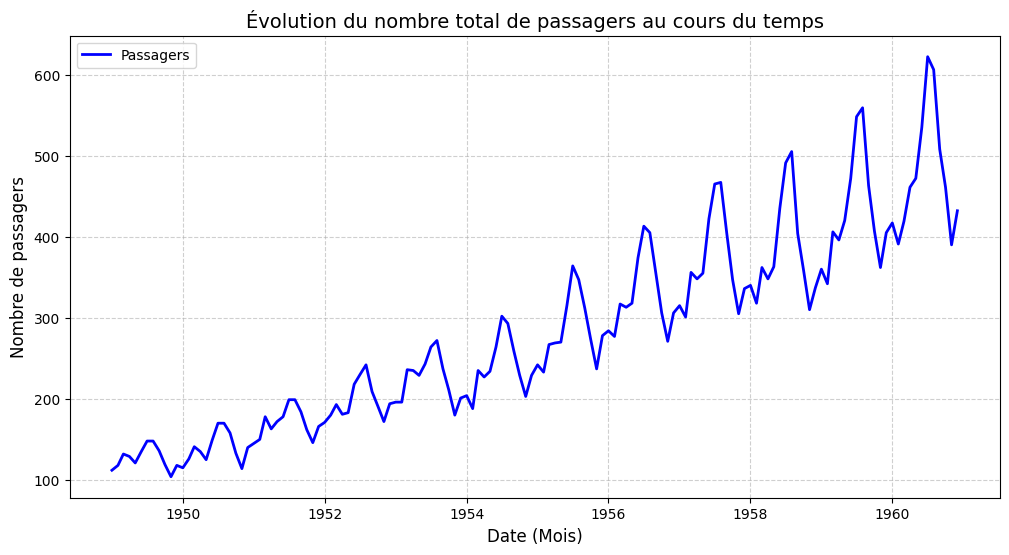

In [11]:
# Création du graphique
plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts.values, label='Passagers', color='blue', linewidth=2)

# Titre et axes
plt.title('Évolution du nombre total de passagers au cours du temps', fontsize=14)
plt.xlabel('Date (Mois)', fontsize=12)
plt.ylabel('Nombre de passagers', fontsize=12)


plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### **3.3 Évolution du Nombre Total de Passagers par An (1949-1960)**

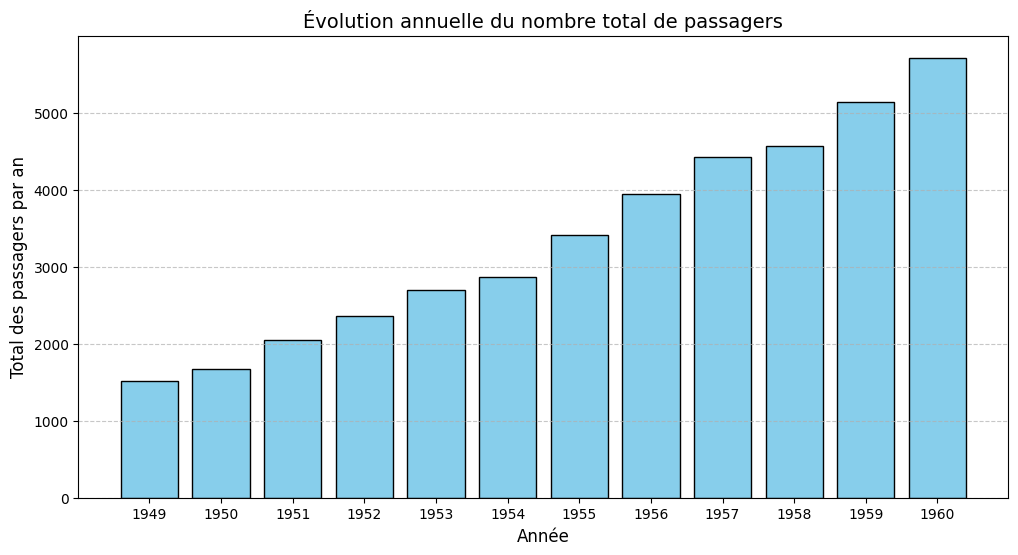

In [12]:
# Regroupement des données par année
ts_annuel = ts.resample('YE').sum()

# Création du graphique 
plt.figure(figsize=(12, 6))
plt.bar(ts_annuel.index.year, ts_annuel.values, color='skyblue', edgecolor='black')

# Titre et axes
plt.title('Évolution annuelle du nombre total de passagers', fontsize=14)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Total des passagers par an', fontsize=12)

plt.xticks(ts_annuel.index.year)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **3.4 Saisonnalité mensuelle : Répartition des passagers par mois**

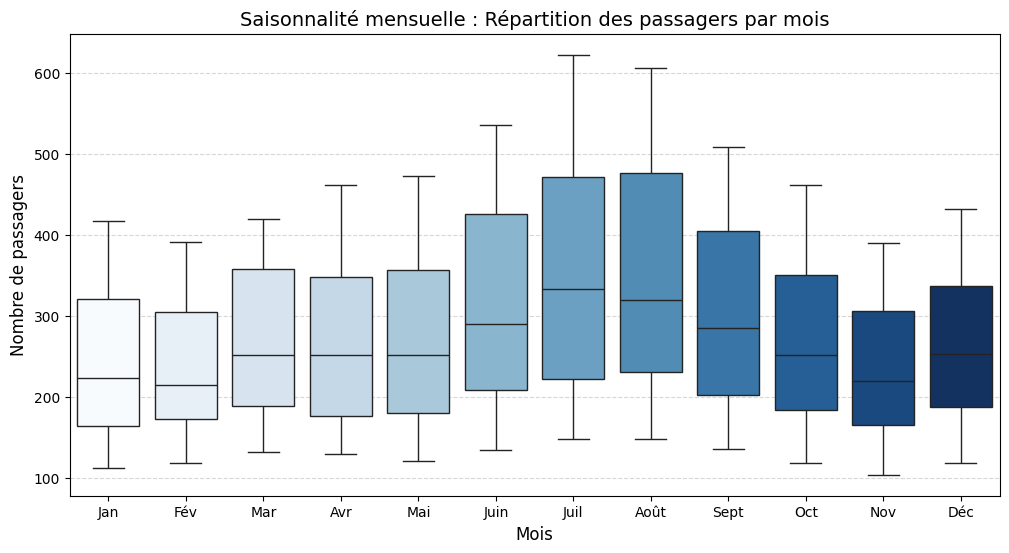

In [13]:
# Création d'un DataFrame temporaire pour séparer les mois et les passagers
df_saison = data.copy()
df_saison['Mois'] = df_saison.index.month

# Création du Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Mois', y='total_passengers', data=df_saison, hue='Mois',palette='Blues', legend=False)

# Titre et axes
plt.title('Saisonnalité mensuelle : Répartition des passagers par mois', fontsize=14)
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Nombre de passagers', fontsize=12)
plt.xticks(range(0, 12), ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sept', 'Oct', 'Nov', 'Déc'])

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

*   **Croissance Annuelle Soutenue :** Le nombre total de passagers a affiché une croissance constante et significative d'année en année.
*   **Saisonnalité Mensuelle Prononcée :** Chaque année, on observe une forte saisonnalité mensuelle, avec un pic systématique des passagers durant les mois d'été (juillet-août), suivi d'une baisse en automne et en hiver.
*   **Performance Saisonnière Inégale :** L'été est clairement la saison la plus fréquentée, enregistrant le plus grand nombre de passagers, tandis que l'hiver est son opposé. Le printemps et l'automne se situent comme saisons intermédiaires.
*   **Tendance Haussière Généralisée :** Indépendamment de la saison, toutes les périodes de l'année ont connu une augmentation du nombre de passagers au fil des ans, ce qui confirme une tendance globale à la hausse du trafic aérien.

## **4. Pré-traitement des données — Décomposition & Stationnarité**

---


Pour une série temporelle, l'Analyse Exploratoire des Données (EDA) cherche à cartographier la structure du signal à travers trois piliers fondamentaux :
> * **La Tendance :** L'orientation à long terme des données. Elle révèle si le phénomène global est en croissance, en décroissance ou s'il stagne.
> * **La Saisonnalité :** Les fluctuations cycliques et prévisibles qui se répètent à intervalles réguliers (ex: pics estivaux, variations hebdomadaires).
> * **La Stationnarité :** Le fait que les propriétés statistiques du signal (moyenne, variance) restent stables dans le temps. C'est le feu vert indispensable pour la plupart des modèles de prévision (comme ARIMA).


### **4.1 Décompoistion**

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Réalisation de la décomposition
# On choisit le modèle 'multiplicative' plutôt que le model='additive' parce que nos données montrent
# une croissance globale et que les variations saisonnières s'amplifient elles aussi avec le temps.
decomposition = seasonal_decompose(ts, model='multiplicative')

In [5]:
# Extraction des différentes composantes
tendance = decomposition.trend
saisonnalite = decomposition.seasonal
residus = decomposition.resid

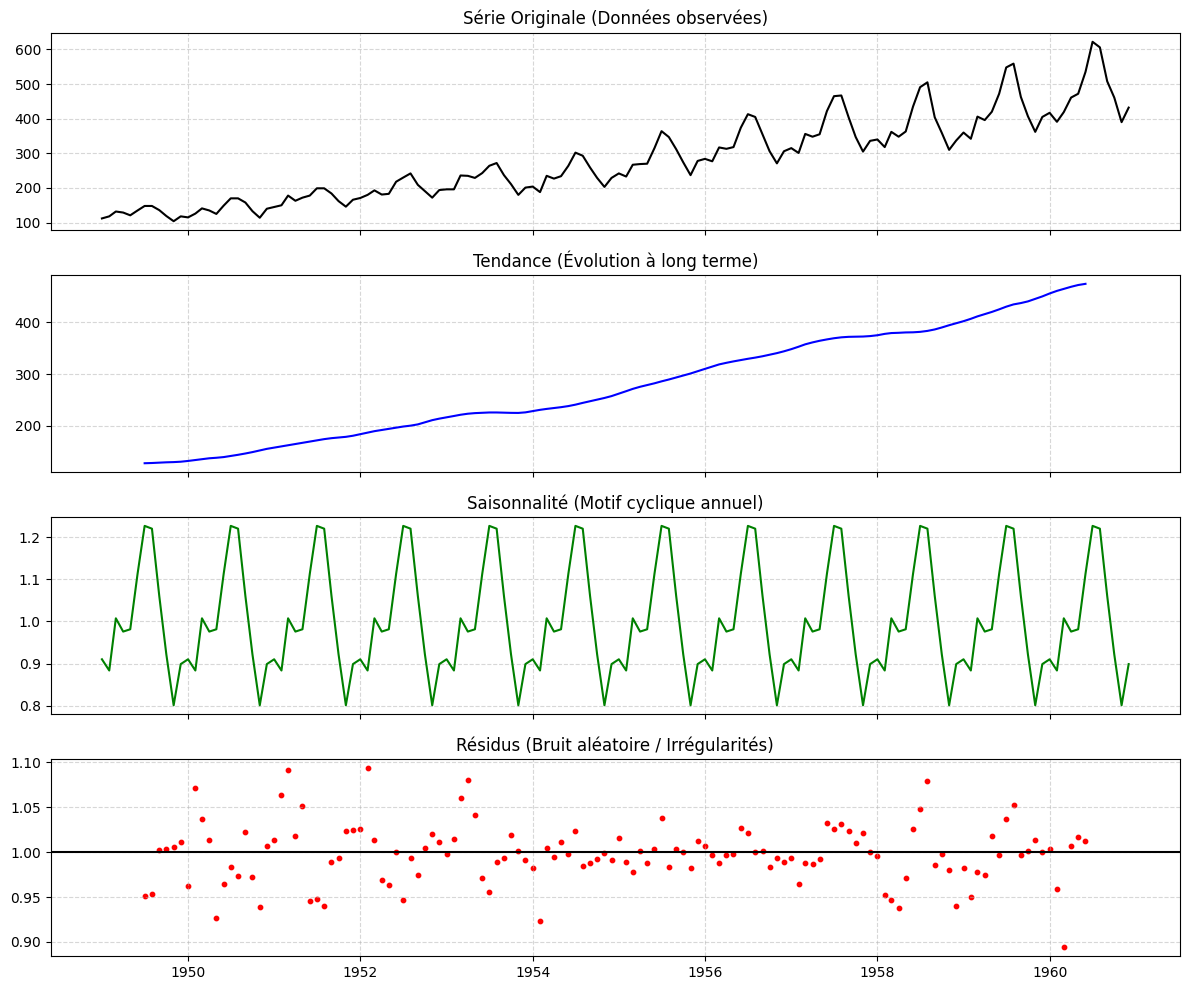

In [6]:
# Affichage des composantes
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Graphique 1 : La série originale
axes[0].plot(ts, color='black', linewidth=1.5)
axes[0].set_title('Série Originale (Données observées)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Graphique 2 : La Tendance (Trend)
axes[1].plot(tendance, color='blue', linewidth=1.5)
axes[1].set_title('Tendance (Évolution à long terme)')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Graphique 3 : La Saisonnalité (Seasonal)
axes[2].plot(saisonnalite, color='green', linewidth=1.5)
axes[2].set_title('Saisonnalité (Motif cyclique annuel)')
axes[2].grid(True, linestyle='--', alpha=0.5)

# Graphique 4 : Les Résidus (Residuals)
axes[3].scatter(residus.index, residus.values, color='red', s=10)
axes[3].axhline(y=1, color='black', linestyle='-')
axes[3].set_title('Résidus (Bruit aléatoire / Irrégularités)')
axes[3].grid(True, linestyle='--', alpha=0.5)

# Ajustement de la mise en page
plt.tight_layout()
plt.show()

**Observations** : 
* **Tendance (Trend)** : on constate que la série montre une croissance linéaire claire au cours des 12 années. Cela indique une augmentation régulière de la demande aérienne sur la période d'étude
* **Saisonnalité (Seasonal)** : on observe un cycle annuel très stable et régulier qui se répète 12 fois. Les mois de juillet-août représentent les pics saisonniers, les mois de novembre-décembre/janvier représentent les creux.
* **Résidus (Residuals)** : Les résidus fluctuent autour de 1.0 avec une amplitude faible (entre 0.90 et 1.10). Cela indique que la décomposition explique bien la majorité de la variance des données. Le bruit est quasi-aléatoire, sans pattern particulier détectable, ce qui est un bon signe car ça signifie que peu d'informations ne sont pas expliquées par le modèle.

### **4.2 Stationnarité**

## **Bibliographie**

* [Analyse des séries temporelles](https://fr.mathworks.com/discovery/time-series-analysis.html)
* [Qu’est-ce qu’un modèle de séries temporelles ?](https://www.ibm.com/fr-fr/think/topics/time-series-model)